Посмотрим на
$$
f(x) = \max\{f_1(x), f_2(x)\}, \quad \text{где} \quad
\begin{cases}
f_1(x) = \mathbf{dist}(x, U), \\
f_2(x) = \mathbf{dist}(x, V).
\end{cases}
$$

Свойства:
* $f_1(x)$ и $f_2(x)$ выпуклы как функции расстояния до выпуклых множеств;
* максимум выпуклых функций — выпуклая функция;
* $f(x) \geq 0$ для всех $x$;
* $f(x) = 0 \Leftrightarrow x \in U \cap V$.

Для минимизации недифференцируемой выпуклой функции $f(x)$ используем субградиентный метод

Для $f(x) = \max\{f_1(x), f_2(x)\}$ субградиент $\partial f(x_k)$ вычисляется так:

1. Если $f_1(x_k) > f_2(x_k)$, то $\partial f(x_k) = \partial f_1(x_k)$.
2. Если $f_1(x_k) < f_2(x_k)$, то $\partial f(x_k) = \partial f_2(x_k)$.
3. Если $f_1(x_k) = f_2(x_k)$, берём любой субградиент из выпуклой оболочки $\partial f_1(x_k) \cup \partial f_2(x_k)$.

Формула для субградиента расстояния:
$$
\partial \mathbf{dist}(x, C) =
\begin{cases}
\frac{x - P_C(x)}{\|x - P_C(x)\|_2}, & \text{если } x \notin C, \\
\{g \in \mathbb{R}^n \mid \|g\|_2 \leq 1\}, & \text{если } x \in C,
\end{cases}
$$
где $P_C(x)$ — проекция точки $x$ на множество $C$.

Проекция на $U$
$$
P_U(x) = y + A^{-1} \left( \frac{\min\{1, \|A(x-y)\|_2\}}{\|A(x-y)\|_2} A(x-y) \right).
$$
Если $\|A(x-y)\|_2 \leq 1$, то $P_U(x) = x$.

Проекция на $V$
$$
(P_V(x))_i = \operatorname{clip}\left(x_i, \left[-\frac{1}{\sigma_i}, \frac{1}{\sigma_i}\right]\right),
$$
где $\operatorname{clip}(a, [b, c]) = \max(b, \min(a, c))$.

### Алгоритм

Вход:
* матрицы $A$, $\Sigma$;
* вектор $y$;
* начальная точка $x_0$;
* последовательность шагов $\alpha_k$ ($c > 0$);
* критерий остановки $\epsilon > 0$.

Выход: приближённая точка $x \in U \cap V$.

Шаги:

1. Инициализация: $k = 0$.
2. Пока $f(x_k) > \epsilon$:
   * Вычислить $P_U(x_k)$ и $d_U = \mathbf{dist}(x_k, U) = \|x_k - P_U(x_k)\|_2$.
   * Вычислить $P_V(x_k)$ и $d_V = \mathbf{dist}(x_k, V) = \|x_k - P_V(x_k)\|_2$.
   * $f(x_k) = \max\{d_U, d_V\}$.
   * **Если** $d_U > d_V$:
     * $g_k = \frac{x_k - P_U(x_k)}{d_U}$.
   * **Иначе если** $d_V > d_U$:
     * $g_k = \frac{x_k - P_V(x_k)}{d_V}$.
   * **Иначе**:
     * Взять $g_k$ как нормализованную сумму субградиентов
   * Обновить: $x_{k+1} = x_k - \alpha_k g_k$.
3. Вернуть $x_k$.

Сходимость
* функция $f(x)$ выпукла и ограничена снизу;
* множество решений непусто;
* субградиентный метод гарантирует сходимость в таком случае (из лекции)


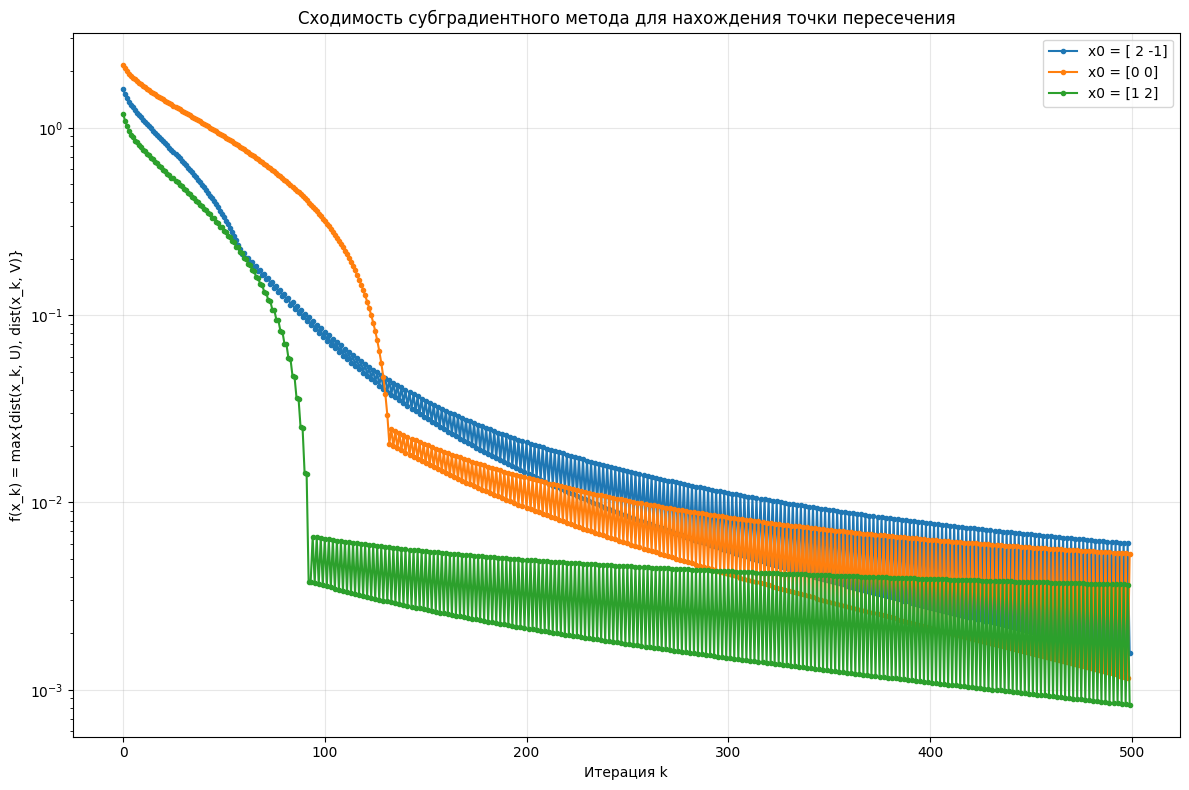

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import brentq

n = 2
y = np.array([3, 2])
sigma = np.array([0.5, 1.0])
A = np.array([[1, 0],
             [-1, 1]])

x0_list = [np.array([2, -1]),
           np.array([0, 0]),
           np.array([1, 2])]

def project_on_V(x, sigma):
    lower_bounds = -1 / sigma
    upper_bounds = 1 / sigma
    return np.clip(x, lower_bounds, upper_bounds)

def distance_to_V(x, sigma):
    proj = project_on_V(x, sigma)
    return np.linalg.norm(x - proj)

def find_lambda_for_U(x, A, y):
    def equation(lambda_val):
        I = np.eye(n)
        M = I + lambda_val * A.T @ A
        rhs = x + lambda_val * A.T @ A @ y
        try:
            P_U = np.linalg.solve(M, rhs)
            residual = A @ (P_U - y)
            return np.linalg.norm(residual) - 1
        except np.linalg.LinAlgError:
            return 1e9

    lambda_opt = brentq(equation, 0, 100)
    return lambda_opt

def project_on_U(x, A, y):
    Ax_minus_Ay = A @ (x - y)
    if np.linalg.norm(Ax_minus_Ay) <= 1:
        return x

    lambda_val = find_lambda_for_U(x, A, y)

    I = np.eye(n)
    M = I + lambda_val * A.T @ A
    rhs = x + lambda_val * A.T @ A @ y
    P_U = np.linalg.solve(M, rhs)
    return P_U

def distance_to_U(x, A, y):
    proj = project_on_U(x, A, y)
    return np.linalg.norm(x - proj)

def subgradient_method(x0, A, y, sigma, max_iter=1000, tol=1e-6, c=0.1):
    x_k = x0.copy()
    objective_history = []

    for k in range(max_iter):
        d_U = distance_to_U(x_k, A, y)
        d_V = distance_to_V(x_k, sigma)

        f_k = max(d_U, d_V)
        objective_history.append(f_k)

        if f_k < tol:
            print(f"Сошлось за {k} итераций, f(x) = {f_k:.2e}")
            break

        P_U_k = project_on_U(x_k, A, y)
        P_V_k = project_on_V(x_k, sigma)

        if d_U > d_V:
            g_k = (x_k - P_U_k) / d_U
        elif d_V > d_U:
            g_k = (x_k - P_V_k) / d_V
        else:
            g1 = (x_k - P_U_k) / d_U if d_U > 0 else np.zeros(n)
            g2 = (x_k - P_V_k) / d_V if d_V > 0 else np.zeros(n)
            g_k = (g1 + g2) / np.linalg.norm(g1 + g2) if np.linalg.norm(g1 + g2) > 0 else g1

        alpha_k = c / np.sqrt(k + 1)
        x_k = x_k - alpha_k * g_k

    return x_k, objective_history

results = []
for i, x0 in enumerate(x0_list):
    x_final, obj_history = subgradient_method(
        x0, A, y, sigma, max_iter=500, tol=1e-6, c=0.1
    )
    results.append((x_final, obj_history))

# Визуализация
plt.figure(figsize=(12, 8))
for i, (x_final, obj_history) in enumerate(results):
    plt.plot(range(len(obj_history)), obj_history,
             label=f'x0 = {x0_list[i]}', marker='o', markersize=3)

plt.xlabel('Итерация k')
plt.ylabel('f(x_k) = max{dist(x_k, U), dist(x_k, V)}')
plt.title('Сходимость субградиентного метода для нахождения точки пересечения')
plt.legend()
plt.grid(True, alpha=0.3)
plt.yscale('log')
plt.tight_layout()
plt.show()

Наша задача является выпуклой как максимум выпуклых, но не сильно выпуклой из-за плоских участков, когда точка находится внутри одного из множеств. Гладкость отсутствует из-за существования точек недифференцируемости в точках пересечения границ множеств. В нашей задаче мы получаем единственное решение, но в общем случае любая точка из пересечения подойдет. Из трех наших точек самый лучший результат дает самая близкая к искомой точка, на втором месте находится (0,0), возможно это из за того что она уже лежит на направлении первых шагов

Вычисление субдифференциала LASOO

Разделим функцию на гладкую и негладкую части:

1. Гладкая часть: $f_1(x) = \frac{1}{2} \|Ax - b\|^2$

Градиент гладкой части:
$$
\nabla f_1(x) = A^T(Ax - b)
$$

2. Негладкая часть: $f_2(x) = \lambda \|x\|_1$

Субдифференциал негладкой части:
$$
\partial f_2(x) = \lambda \cdot \partial \|x\|_1,
$$
где $\partial \|x\|_1 = \{g \in \mathbb{R}^n \mid g_i \in \partial |x_i|\}$, а
$$
\partial |x_i| =
\begin{cases}
\{1\}, & x_i > 0, \\
\{-1\}, & x_i < 0, \\
[-1, 1], & x_i = 0.
\end{cases}
$$

Итоговый субдифференциал:
$$
\partial f(x) = A^T(Ax - b) + \lambda \cdot g, \quad \text{где } g_i \in
\begin{cases}
1, & x_i > 0, \\
-1, & x_i < 0, \\
[-1, 1], & x_i = 0.
\end{cases}
$$


Правило обновления субградиентного метода:
$$
x_{k+1} = x_k - \alpha_k g_k, \quad g_k \in \partial f(x_k)
$$

Вычислительная сложность итерации:
- Вычисление $Ax_k$ - $O(mn)$
- Вычисление $A^T(Ax_k - b)$ - $O(mn)$
- Нахождение субградиента $g_k$ - $O(n)$
- Обновление $x_{k+1}$ - $O(n)$

**Общая сложность одной итерации:** $O(mn)$ операций.


Running Constant (α=0.001)...
Running Constant length (γ=0.1)...
Running Inverse sqrt...
Running Inverse...
Running Polyak (γ_k=10/(10+k))...


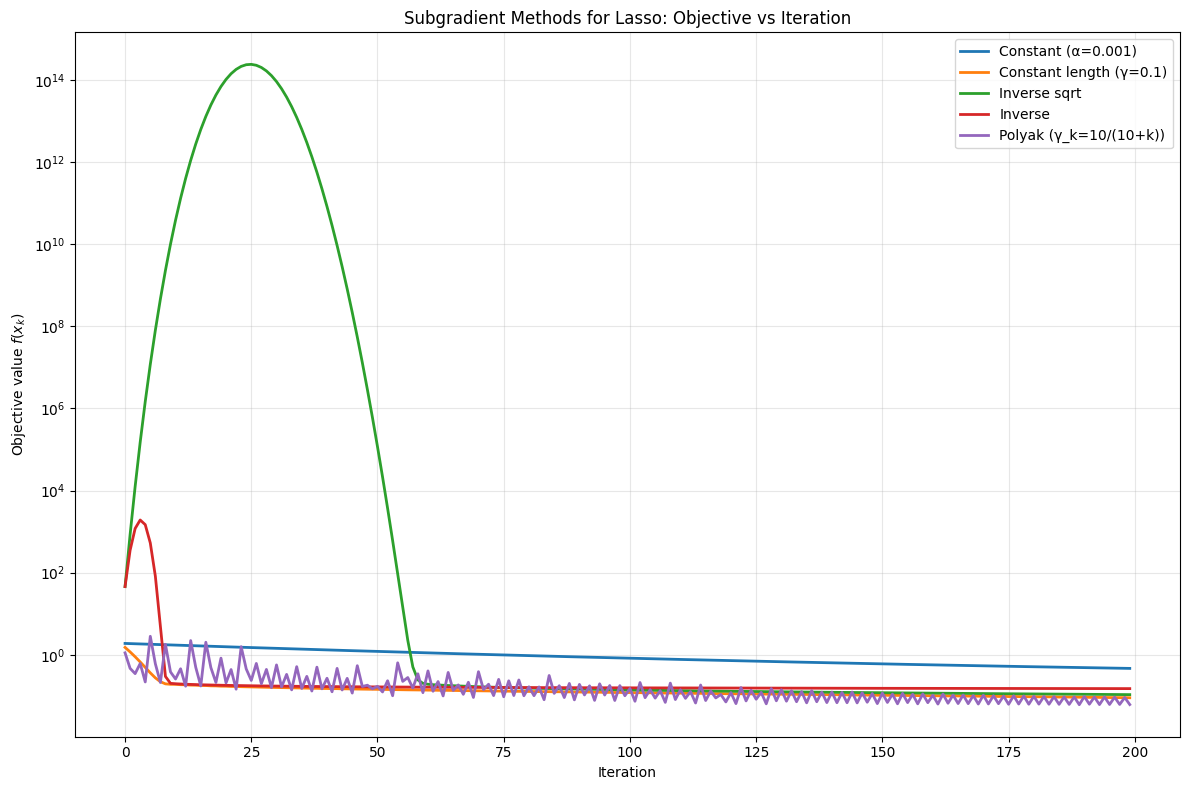

In [8]:
import numpy as np
import matplotlib.pyplot as plt

n, m, k = 1000, 200, 5
lambda_reg = 0.01

np.random.seed(42)
A = np.random.randn(m, n) / np.sqrt(m)
x_true = np.zeros(n)
x_true[:k] = 1
b = A @ x_true

def objective(x, A, b, lambda_reg):
    return 0.5 * np.linalg.norm(A @ x - b)**2 + lambda_reg * np.sum(np.abs(x))

def subgradient(x, A, b, lambda_reg):
    grad_smooth = A.T @ (A @ x - b)
    subgrad_l1 = np.zeros_like(x)
    subgrad_l1[x > 0] = 1
    subgrad_l1[x < 0] = -1
    return grad_smooth + lambda_reg * subgrad_l1

def subgradient_method(A, b, lambda_reg, x0, step_rule, max_iter=2000):
    x = x0.copy()
    obj_history = []

    for k in range(max_iter):
        g = subgradient(x, A, b, lambda_reg)

        alpha = step_rule(k, x, g, obj_history)

        x = x - alpha * g

        obj_val = objective(x, A, b, lambda_reg)
        obj_history.append(obj_val)

    return np.array(obj_history)

def constant_step(k, x, g, history, alpha=0.001):
    return alpha

def constant_length(k, x, g, history, gamma=0.1):
    norm_g = np.linalg.norm(g)
    if norm_g == 0:
        return 0
    return gamma / norm_g

def inverse_sqrt(k, x, g, history):
    return 1 / np.sqrt(k + 1)

def inverse(k, x, g, history):
    return 1 / (k + 1)

def polyak_step(k, x, g, history, f_best_estimate=None, gamma_k_func=None):
    if f_best_estimate is None:
        f_best_estimate = min(history) if history else objective(x, A, b, lambda_reg)
    if gamma_k_func is None:
        gamma_k_func = lambda k: 10 / (10 + k)

    f_current = objective(x, A, b, lambda_reg)
    gamma_k = gamma_k_func(k)
    norm_g_sq = np.linalg.norm(g)**2

    if norm_g_sq == 0:
        return 0

    return (f_current - f_best_estimate + gamma_k) / norm_g_sq

x0 = np.zeros(n)
max_iter = 200

rules = {
    'Constant (α=0.001)': lambda k, x, g, hist: constant_step(k, x, g, hist, alpha=0.001),
    'Constant length (γ=0.1)': lambda k, x, g, hist: constant_length(k, x, g, hist, gamma=0.1),
    'Inverse sqrt': inverse_sqrt,
    'Inverse': inverse,
    'Polyak (γ_k=10/(10+k))': lambda k, x, g, hist: polyak_step(
        k, x, g, hist,
        gamma_k_func=lambda k: 10 / (10 + k)
    )
}

results = {}
for name, rule in rules.items():
    print(f"Running {name}...")
    obj_hist = subgradient_method(A, b, lambda_reg, x0, rule, max_iter)
    results[name] = obj_hist


# Визуализация
plt.figure(figsize=(12, 8))
for name, obj_hist in results.items():
    plt.plot(obj_hist, label=name, linewidth=2)

plt.xlabel('Iteration')
plt.ylabel('Objective value $f(x_k)$')
plt.title('Subgradient Methods for Lasso: Objective vs Iteration')
plt.legend()
plt.grid(True, alpha=0.3)
plt.yscale('log')
plt.tight_layout()
plt.show()


In [10]:
def heavy_ball_method(A, b, lambda_reg, x0, step_rule, beta=0.9, max_iter=2000):
    x_prev = x0.copy()
    x_curr = x0.copy()
    obj_history = []

    for k in range(max_iter):
        g = subgradient(x_curr, A, b, lambda_reg)
        alpha = step_rule(k, x_curr, g, obj_history)

        if k == 0:
            x_next = x_curr - alpha * g
        else:
            momentum = beta * (x_curr - x_prev)
            x_next = x_curr - alpha * g + momentum

        x_prev = x_curr.copy()
        x_curr = x_next.copy()

        obj_val = objective(x_curr, A, b, lambda_reg)
        obj_history.append(obj_val)

    return np.array(obj_history)

Running Heavy Ball with β = 0.1...
  HB β=0.1 (Constant (α=0.001))
  HB β=0.1 (Constant length (γ=0.1))
  HB β=0.1 (Inverse sqrt)
  HB β=0.1 (Inverse)
  HB β=0.1 (Polyak (γ_k=10/(10+k)))
Running Heavy Ball with β = 0.5...
  HB β=0.5 (Constant (α=0.001))
  HB β=0.5 (Constant length (γ=0.1))
  HB β=0.5 (Inverse sqrt)
  HB β=0.5 (Inverse)
  HB β=0.5 (Polyak (γ_k=10/(10+k)))
Running Heavy Ball with β = 0.7...
  HB β=0.7 (Constant (α=0.001))
  HB β=0.7 (Constant length (γ=0.1))
  HB β=0.7 (Inverse sqrt)
  HB β=0.7 (Inverse)
  HB β=0.7 (Polyak (γ_k=10/(10+k)))
Running Heavy Ball with β = 0.9...
  HB β=0.9 (Constant (α=0.001))
  HB β=0.9 (Constant length (γ=0.1))
  HB β=0.9 (Inverse sqrt)
  HB β=0.9 (Inverse)
  HB β=0.9 (Polyak (γ_k=10/(10+k)))


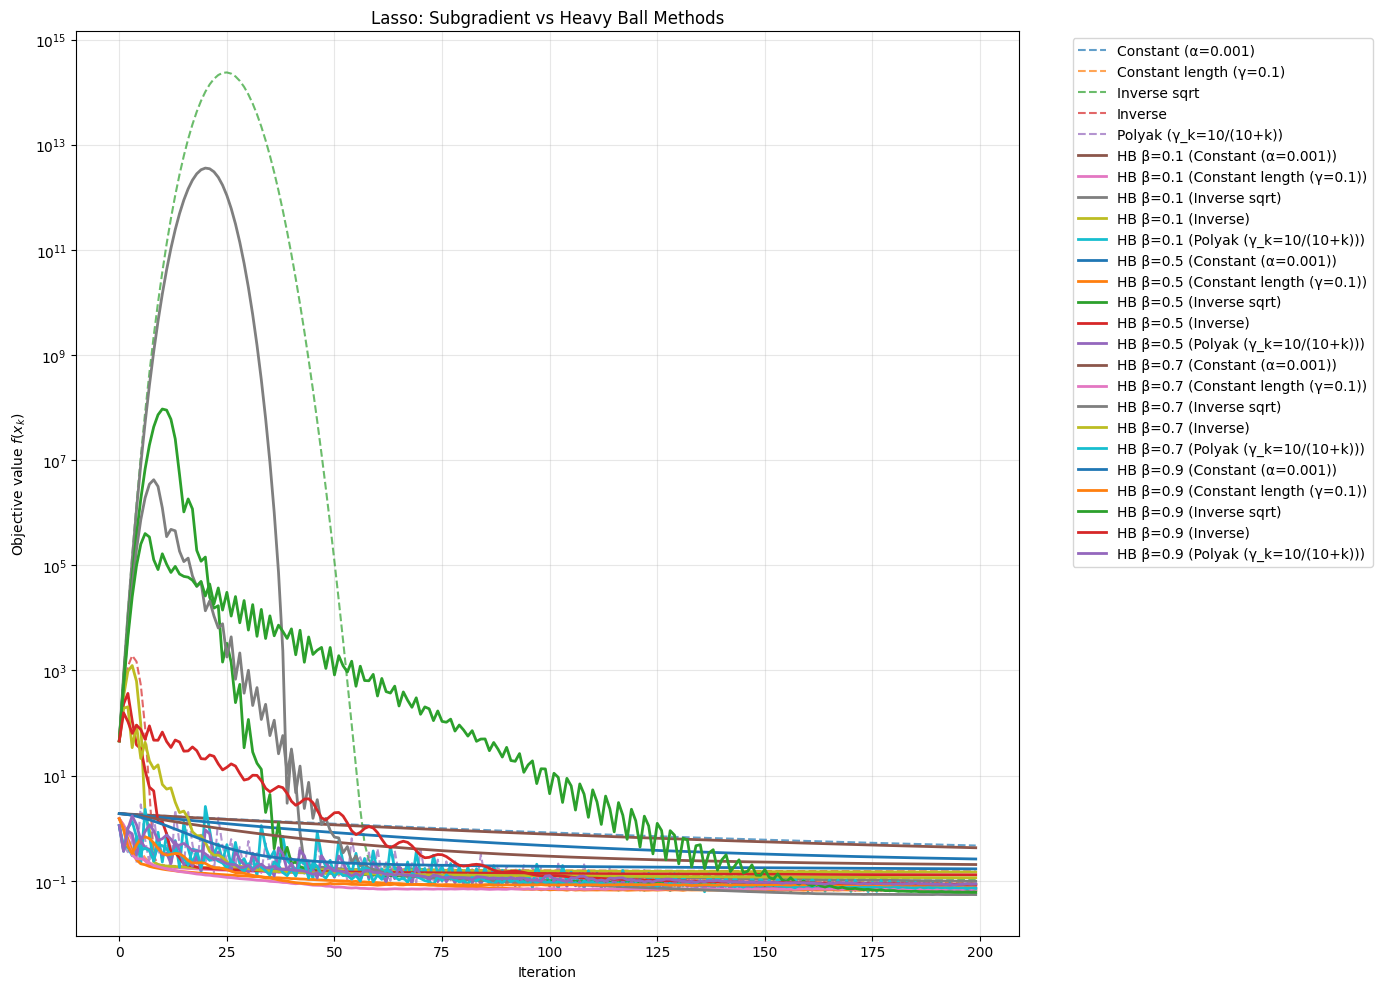

In [11]:
beta_values = [0.1, 0.5, 0.7, 0.9]
heavy_ball_results = {}

for beta in beta_values:
    print(f"Running Heavy Ball with β = {beta}...")
    for name, rule in rules.items():
        key = f"HB β={beta} ({name})"
        print(f"  {key}")
        obj_hist = heavy_ball_method(
            A, b, lambda_reg, x0, rule, beta=beta, max_iter=max_iter
        )
        heavy_ball_results[key] = obj_hist

plt.figure(figsize=(14, 10))

for name, obj_hist in results.items():
    plt.plot(obj_hist, label=name, linestyle='--', alpha=0.7)

for key, obj_hist in heavy_ball_results.items():
    plt.plot(obj_hist, label=key, linewidth=2)

plt.xlabel('Iteration')
plt.ylabel('Objective value $f(x_k)$')
plt.title('Lasso: Subgradient vs Heavy Ball Methods')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3)
plt.yscale('log')
plt.tight_layout()
plt.show()
